# 📈 Market Investments Analysis

This notebook analyzes historical S&P 500 data to demonstrate the importance of long-term investing, especially through market downturns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style='darkgrid')
plt.rcParams["figure.figsize"] = (14, 6)

## 📥 Load Data

In [2]:
df = pd.read_csv("data/S&P500.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
1980-05-01,106.29,106.86,104.72,105.46,18044444.0
1980-05-02,105.46,106.25,104.61,105.58,15577778.0
1980-05-05,105.58,106.83,104.64,106.38,18938889.0
1980-05-06,106.38,107.83,105.36,106.25,22311111.0
1980-05-07,106.25,108.12,105.83,107.18,23666667.0


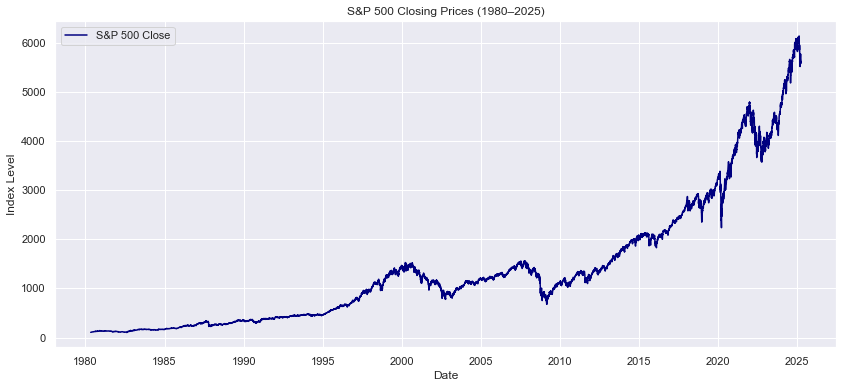

In [3]:
plt.plot(df['Close'], label='S&P 500 Close', color='navy')
plt.title("S&P 500 Closing Prices (1980–2025)")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.legend()
plt.show()

## 📌 Key Insight
>S&P 500 has always recovered and gone up after every major crashes


## 📉 Calculate Drawdowns

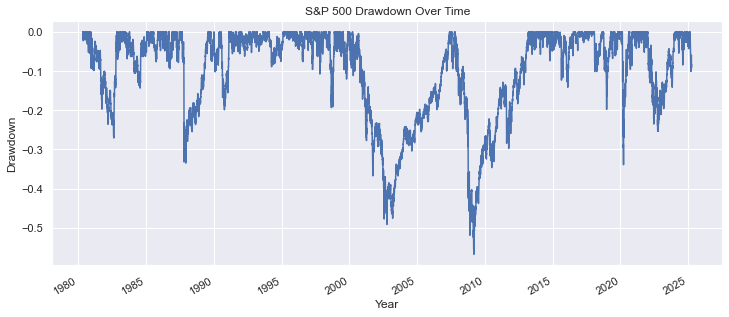

In [4]:
df['Peak'] = df['Close'].cummax()
df['Drawdown'] = (df['Close'] - df['Peak']) / df['Peak']
df['Drawdown'].plot(figsize=(12, 5), title="S&P 500 Drawdown Over Time")
plt.ylabel("Drawdown")
plt.xlabel("Year")
plt.show()


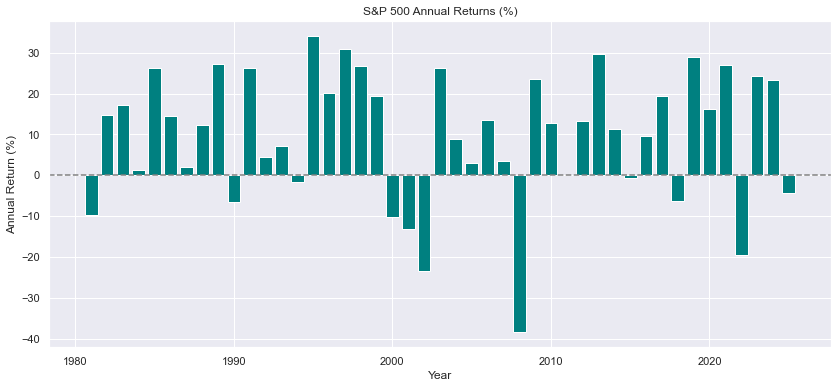

In [45]:
df['Year'] = df.index.year
annual_returns = df['Close'].resample('Y').last().pct_change() * 100

plt.bar(annual_returns.index.year[1:], annual_returns[1:], color='teal')
plt.title("S&P 500 Annual Returns (%)")
plt.xlabel("Year")
plt.ylabel("Annual Return (%)")
plt.axhline(0, color='gray', linestyle='--')
plt.show()

## 📊 Simulate 10, 15 and 20 Year CAGR (Compounded Annual Growth Rate)

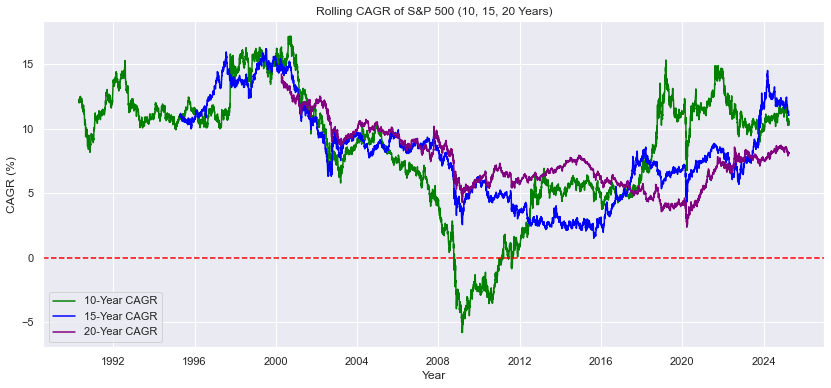

In [5]:
def calculate_cagr(series, years):
    return (series / series.shift(years * 252)) ** (1 / years) - 1

df['10Y_CAGR'] = calculate_cagr(df['Close'], 10) * 100
df['15Y_CAGR'] = calculate_cagr(df['Close'], 15) * 100
df['20Y_CAGR'] = calculate_cagr(df['Close'], 20) * 100

# 📈 Plot all 3 CAGRs
plt.figure(figsize=(14, 6))
plt.plot(df['10Y_CAGR'], label='10-Year CAGR', color='green')
plt.plot(df['15Y_CAGR'], label='15-Year CAGR', color='blue')
plt.plot(df['20Y_CAGR'], label='20-Year CAGR', color='purple')
plt.title("Rolling CAGR of S&P 500 (10, 15, 20 Years)")
plt.ylabel("CAGR (%)")
plt.xlabel("Year")
plt.axhline(0, color='red', linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

## 📌 Key Insight

> Despite market crashes, the 10-year, 15year and 20-year CAGR rarely stays negative—reinforcing the idea that long-term investors are always rewarded. Also note that longer the investment period lower is the risk associated with the same.

## 📅 Summary of Recovery Periods

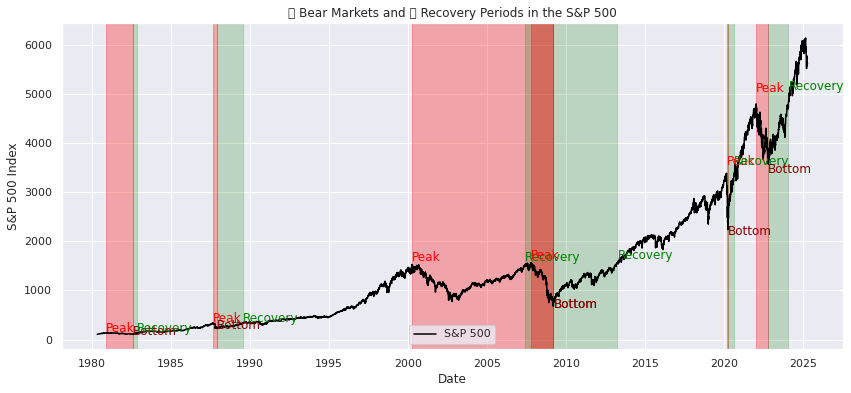

In [7]:
# Recalculate Peak and Drawdown just in case
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'  # Replace with a font that supports emojis

df['Peak'] = df['Close'].cummax()
df['Drawdown'] = (df['Close'] - df['Peak']) / df['Peak'] * 100

bear_markets = []
in_bear = False
peak_date = bottom_date = recovery_date = None
peak_value = 0

for i in range(1, len(df)):
    current_close = df['Close'].iloc[i]
    current_date = df.index[i]

    if not in_bear:
        # Check if drawdown exceeds -20%
        if df['Drawdown'].iloc[i] <= -20:
            in_bear = True
            peak_date = df['Close'][:i].idxmax()
            peak_value = df.loc[peak_date, 'Close']
            bottom_date = df['Close'].iloc[i:].idxmin()
    else:
        # Check for recovery above previous peak
        if current_close >= peak_value:
            recovery_date = current_date
            bear_markets.append((peak_date, bottom_date, recovery_date))
            in_bear = False
            peak_date = bottom_date = recovery_date = None
            peak_value = 0

# 🧭 Plot the S&P 500 with Bear Markets Highlighted
plt.figure(figsize=(14, 6))
plt.plot(df['Close'], label='S&P 500', color='black')

for peak, bottom, recovery in bear_markets:
    # Shade Bear Market (Red)
    plt.axvspan(peak, bottom, color='red', alpha=0.3)
    # Shade Recovery (Green)
    plt.axvspan(bottom, recovery, color='green', alpha=0.2)
    plt.text(peak, df.loc[peak, 'Close'] * 1.05, 'Peak', color='red')
    plt.text(bottom, df.loc[bottom, 'Close'] * 0.95, 'Bottom', color='darkred')
    plt.text(recovery, df.loc[recovery, 'Close'] * 1.05, 'Recovery', color='green')

plt.title("📉 Bear Markets and 📈 Recovery Periods in the S&P 500")
plt.xlabel("Date")
plt.ylabel("S&P 500 Index")
plt.legend()
plt.grid(True)
plt.show()


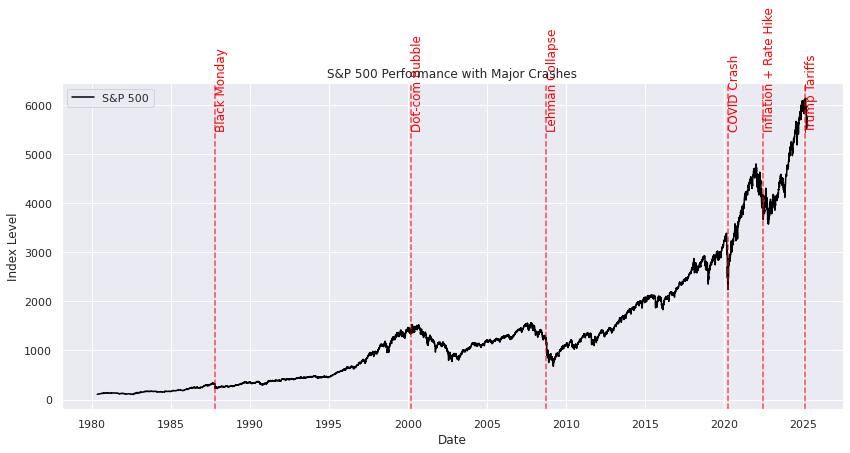

In [8]:
crash_dates = [
    ('1987-10-19', 'Black Monday'),
    ('2000-03-10', 'Dot-com Bubble'),
    ('2008-09-15', 'Lehman Collapse'),
    ('2020-03-20', 'COVID Crash'),
    ('2022-06-01', 'Inflation + Rate Hike'),
    ('2025-02-01', 'Trump Tariffs')
]

plt.plot(df['Close'], label='S&P 500', color='black')

for date, label in crash_dates:
    plt.axvline(pd.to_datetime(date), color='red', linestyle='--', alpha=0.7)
    plt.text(pd.to_datetime(date), df['Close'].max() * 0.9, label, rotation=90, color='red')

plt.title("S&P 500 Performance with Major Crashes")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.legend()
plt.show()

In [9]:
start_value = df['Close'].iloc[0]
end_value = df['Close'].iloc[-1]
total_years = (df.index[-1] - df.index[0]).days / 365.25
cagr = (end_value / start_value) ** (1 / total_years) - 1

print(f"📈 From {df.index[0].date()} to {df.index[-1].date()},")
print(f"S&P 500 grew from {start_value:.2f} to {end_value:.2f} over {total_years:.1f} years.")
print(f"Compound Annual Growth Rate (CAGR): {cagr*100:.2f}% per year")


📈 From 1980-05-01 to 2025-04-01,
S&P 500 grew from 105.46 to 5633.07 over 44.9 years.
Compound Annual Growth Rate (CAGR): 9.26% per year


In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the S&P 500 data
df = pd.read_csv("data/S&P500.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Define the investment period
investment_start_date = pd.to_datetime("2008-12-09")
investment_end_date = pd.to_datetime("2024-07-01")

# Filter for available start and end prices
start_row = df[df["Date"] >= investment_start_date].iloc[0]
end_row = df[df["Date"] <= investment_end_date].iloc[-1]

start_price = start_row["Close"]
end_price = end_row["Close"]

# Calculate investment growth
initial_investment = 10000
final_value = (end_price / start_price) * initial_investment
growth_multiplier = final_value / initial_investment

# Print the investment summary
print(f"Initial Investment Date: {start_row['Date'].date()}")
print(f"Initial Investment Amount: {initial_investment}" )
print(f"Start Price: ${start_price:.2f}")
print(f"End Price: ${end_price:.2f}")
print(f"Final Portfolio Value in 2024: ${final_value:,.2f}")
print(f"Total Growth: {growth_multiplier:.2f}x")



Initial Investment Date: 2008-12-09
Initial Investment Amount: 10000
Start Price: $888.67
End Price: $5475.09
Final Portfolio Value in 2024: $61,609.93
Total Growth: 6.16x
